# Softmax Regression — từ công thức toán đến code (4 giai đoạn) trên Iris

**Môn học:** Học máy nâng cao (ml_ad) · **Học viên:** Nguyễn Phương Anh Tú · **MSHV:** 2611328

Báo cáo đầy đủ (lý thuyết, lịch sử, tham khảo): [`../report_softmax_regression.md`](../report_softmax_regression.md).

> **Phương pháp của môn (áp dụng cho mọi thuật toán).** Notebook triển khai theo đúng 4 giai đoạn, có lý do cho từng bước:
> 1. **Giải tay** — dẫn kiến thức toán từng bước trước khi viết mã.
> 2. **Bản thuần, KHÔNG thư viện** — cài từ công thức bằng NumPy, kiểm chứng gradient bằng sai phân hữu hạn.
> 3. **Bản thư viện** — `scikit-learn`, solver công nghiệp.
> 4. **Bản framework** — `PyTorch` (sau cùng).
>
> Bốn cách cho cùng độ chính xác trên Iris — minh chứng bản thuần cài **đúng**.

**Bài toán:** phân loại 3 loài hoa Iris (*setosa, versicolor, virginica*) theo 4 đặc trưng: chiều dài/rộng đài hoa và cánh hoa. Đây là bài toán phân loại đa lớp ($K=3$) kinh điển; softmax regression là mô hình tuyến tính tiêu chuẩn cho nó.

## 0. Nạp dữ liệu Iris và tiền xử lý

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

X_all, y_all = load_iris(return_X_y=True)
feat = ["sepal_len", "sepal_wid", "petal_len", "petal_wid"]
cls = ["setosa", "versicolor", "virginica"]
print("So mau:", len(y_all), "| so dac trung:", X_all.shape[1], "| so lop:", len(cls))
print("Phan bo lop:", dict(zip(cls, np.bincount(y_all))))
print("1 mau dau (setosa):", X_all[0], "-> lop", y_all[0])

# Chia 70/30 co phan tang (stratify) de giu ti le lop, co dinh seed de tai lap
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3,
                                          random_state=1, stratify=y_all)
# CHUAN HOA dac trung (trung binh 0, do lech 1) - chi fit tren train
sc = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = sc.transform(X_tr), sc.transform(X_te)
print("\nKich thuoc train/test:", X_tr_s.shape, X_te_s.shape)
print("Trung binh train (sau chuan hoa) ~", X_tr_s.mean(0).round(3))

So mau: 150 | so dac trung: 4 | so lop: 3
Phan bo lop: {'setosa': np.int64(50), 'versicolor': np.int64(50), 'virginica': np.int64(50)}
1 mau dau (setosa): [5.1 3.5 1.4 0.2] -> lop 0

Kich thuoc train/test: (105, 4) (45, 4)
Trung binh train (sau chuan hoa) ~ [ 0. -0.  0.  0.]


## 1. Vì sao cần softmax? (không dùng sigmoid cho đa lớp)

Với 2 lớp, hồi quy logistic dùng sigmoid $\sigma(z) \in (0,1)$ cho một xác suất. Với $K$ lớp, cần **một phân phối xác suất** trên $K$ đầu ra (mỗi giá trị dương và tổng đúng bằng 1). Hàm **softmax** đáp ứng yêu cầu đó. Nó là tổng quát hoá tự nhiên của sigmoid (với $K=2$ hai cách cho kết quả tương đương).

## 2. Mô hình và hàm mất mát

**Điểm số (logit).** Với trọng số $W \in \mathbb{R}^{d \times K}$ và thiên lệch $b \in \mathbb{R}^K$:
$$z = W^\top x + b \in \mathbb{R}^K.$$

**Softmax** biến điểm số thành xác suất:
$$\hat{y}_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}, \qquad \sum_k \hat{y}_k = 1.$$

**Mất mát entropy chéo** của một mẫu (nhãn one-hot $y$, lớp đúng $c$):
$$\ell = -\sum_{k=1}^{K} y_k \log \hat{y}_k = -\log \hat{y}_c.$$

Trên cả tập $N$ mẫu, ta cực tiểu hoá $\mathcal{L} = -\tfrac{1}{N}\sum_i \log \hat{y}_{i,c_i}$.

## 3. GIẢI TAY — dẫn xuất gradient từng bước

Mục tiêu: tính $\partial \mathcal{L}/\partial W$ và $\partial \mathcal{L}/\partial b$ để biết cập nhật trọng số thế nào.

**Bước 1. Đạo hàm theo logit.** Với $\hat{y}_k = e^{z_k}/\sum_j e^{z_j}$ và $\ell = -\sum_k y_k \log \hat{y}_k$, ta chứng minh được:
$$\frac{\partial \ell}{\partial z_m} = \hat{y}_m - y_m.$$
(Chi tiết: $\partial \log \hat{y}_k / \partial z_m = \mathbb{1}[k=m] - \hat{y}_m$; thay vào và dùng $\sum_k y_k = 1$.)

**Bước 2. Theo trọng số và thiên lệch.** Vì $z_m = W_{\cdot m}^\top x + b_m$:
$$\frac{\partial \ell}{\partial W_{jm}} = x_j(\hat{y}_m - y_m), \qquad \frac{\partial \ell}{\partial b_m} = \hat{y}_m - y_m.$$

**Bước 3. Gộp cả batch.** Đặt $P \in \mathbb{R}^{N\times K}$ là ma trận xác suất, $Y \in \{0,1\}^{N\times K}$ là one-hot:
$$\boxed{\;\frac{\partial \mathcal{L}}{\partial W} = \frac{1}{N} X^\top (P - Y), \qquad \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{N}\mathbf{1}^\top (P - Y)\;}$$

**Tính đẹp của softmax + entropy chéo:** gradient của logit chỉ là $(P - Y)$ — sai số dự đoán trừ nhãn. Nhờ vậy bản thuần chỉ cần hai phép ma trận, không cần đạo hàm bậc hai hay autograd. Bước tiếp theo kiểm chứng công thức này bằng **sai phân hữu hạn**.

### 3bis. Giải tay với số cụ thể (thay số vào công thức)

Để người mới học thấy công thức "chạy" thế nào, ta thay số từng bước cho đúng mẫu đầu tiên của Iris.

**Bảng ý nghĩa từng kí hiệu** — đọc trước khi xem tính toán:

| Kí hiệu | Đọc là | Ý nghĩa | Kích thước | Giá trị ở mẫu này |
|---|---|---|---|---|
| `x` | "x" | vector đặc trưng của 1 bông hoa (4 số đo) | (4,) | [5.1, 3.5, 1.4, 0.2] |
| `W` | "W" | ma trận trọng số — mỗi **cột** là trọng số của 1 lớp | (4, 3) | (cho ở dưới) |
| `b` | "b" | thiên lệch (bias) của 3 lớp | (3,) | [0, 0.1, 0] |
| `z = W·x + b` | "z" | **điểm số thô** (logit) của 3 lớp; càng cao càng giống lớp đó | (3,) | [2.91, 4.03, 4.95] |
| `p = softmax(z)` | "p" | **xác suất** 3 lớp (dương, tổng = 1) | (3,) | [0.085, 0.261, 0.654] |
| `y` | "y" | nhãn thật dạng **one-hot** (lớp đúng = 1, còn lại 0) | (3,) | [1, 0, 0] (setosa) |
| `ℓ` | "ell" | **mất mát** entropy chéo của mẫu (càng nhỏ càng tốt) | số | 2.464 |
| `∂ℓ/∂z = p − y` | "grad-z" | đạo hàm mất mát theo điểm số — cho *hướng* cần sửa | (3,) | [−0.915, 0.261, 0.654] |

**Đầu vào cụ thể.** Mẫu setosa đầu tiên: `x = [5.1, 3.5, 1.4, 0.2]` (đài dài, đài rộng, cánh dài, cánh rộng). Bộ trọng số minh hoạ:
`W = [[0.1, 0.2, 0.3], [0.4, 0.5, 0.6], [0.7, 0.8, 0.9], [0.1, 0.2, 0.3]]` (4×3),  `b = [0, 0.1, 0]`.

**Bước 1 — Điểm số `z = W·x + b`** (mỗi lớp = tích vô hướng giữa `x` và một cột của `W`, cộng thiên lệch):
- `z₀ = 0.1·5.1 + 0.4·3.5 + 0.7·1.4 + 0.1·0.2 + 0   = 2.91`  → điểm số lớp setosa
- `z₁ = 0.2·5.1 + 0.5·3.5 + 0.8·1.4 + 0.2·0.2 + 0.1 = 4.03`  → lớp versicolor
- `z₂ = 0.3·5.1 + 0.6·3.5 + 0.9·1.4 + 0.3·0.2 + 0   = 4.95`  → lớp virginica

**Bước 2 — Softmax** (trừ max trước khi lấy exp để chống tràn số). `max(z) = 4.95`, nên `z′ = z − 4.95 = [−2.04, −0.92, 0]`:
- `exp(z′) = [0.130, 0.399, 1.000]`,  tổng = `1.528`
- `p = exp(z′) / 1.528 = [0.085, 0.261, 0.654]`  → mô hình đoán virginica (0.654 cao nhất) → **sai** (mẫu là setosa).

**Bước 3 — Mất mát entropy chéo.** Nhãn thật lớp 0 ⇒ `y = [1, 0, 0]`. Entropy chéo **chỉ phạt lớp đúng**:
`ℓ = −log(p₀) = −log(0.085) = 2.464`
Loss lớn vì mô hình gán xác suất rất thấp (0.085) cho lớp đúng — càng sai càng phạt nặng.

**Bước 4 — Gradient** `∂ℓ/∂z = p − y` (công thức đã dẫn ở Mục 3):
`∂ℓ/∂z = [0.085−1,  0.261−0,  0.654−0] = [−0.915, 0.261, 0.654]`
- **Âm** ở lớp 0 (−0.915): gradient âm ⇒ gradient descent **tăng** `z₀` lên → `p₀` lớn hơn (đúng hướng, vì lớp 0 mới là đúng).
- **Dương** ở lớp 1, 2: gradient descent **giảm** `z₁, z₂` → bớt đoán nhầm.

Cell kế tiếp chạy đúng các con số trên bằng mã, **vẽ thành sơ đồ** để xem, và đối chiếu gradient giải tích với sai phân hữu hạn.

In [2]:
# === Giai doan 1: GIAI TAY tren 1 mau ===
x0 = X_all[0].astype(float)                     # setosa dau tien
W0 = np.array([[.1,.2,.3],[.4,.5,.6],[.7,.8,.9],[.1,.2,.3]])  # (4,3)
b0 = np.array([0.0, 0.1, 0.0])
z0 = W0.T @ x0 + b0
print("z   =", z0)
p0 = np.exp(z0 - z0.max()); p0 /= p0.sum()      # softmax ON DINH (tru max)
print("p   =", p0, " (tong = %.4f)" % p0.sum())
y0 = np.array([1, 0, 0], dtype=float)           # setosa -> lop 0
loss0 = -np.sum(y0 * np.log(p0))
print("loss (entropy cheo) = %.4f" % loss0)
grad_z0 = p0 - y0
print("dL/dz = p - y =", grad_z0)
print("dL/dW = x (p-y)^T ->\n", np.round(np.outer(x0, grad_z0), 3))

# === Kiem chung gradient bang sai phân huu han tren ca batch ===
K = 3
def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)        # tru max: chong tran (overflow)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

def loss_and_grad(W, b, X, Y):
    P = softmax(X @ W + b); n = len(X)
    L = -np.mean(np.sum(Y * np.log(P + 1e-12), axis=1))
    gW = X.T @ (P - Y) / n
    gb = (P - Y).mean(axis=0)
    return L, gW, gb

Y_tr = np.eye(K)[y_tr]
rng = np.random.default_rng(0)
W = rng.normal(size=(4, K)) * 0.1; b = np.zeros(K)
L, gW, gb = loss_and_grad(W, b, X_tr_s, Y_tr)

eps = 1e-6
gW_num = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        Wp = W.copy(); Wp[i, j] += eps
        Lp, _, _ = loss_and_grad(Wp, b, X_tr_s, Y_tr)
        Wm = W.copy(); Wm[i, j] -= eps
        Lm, _, _ = loss_and_grad(Wm, b, X_tr_s, Y_tr)
        gW_num[i, j] = (Lp - Lm) / (2 * eps)
diff = np.abs(gW - gW_num).max()
print("\nKiem chung gradient: max|giai tich - sai phan| = %.2e" % diff)
print("=> cong thuc o Muc 3 DUNG" if diff < 1e-6 else "=> CONG THUC SAI, can xem lai")

z   = [2.91 4.03 4.95]
p   = [0.0851 0.2607 0.6542]  (tong = 1.0000)
loss (entropy cheo) = 2.4643
dL/dz = p - y = [-0.9149  0.2607  0.6542]
dL/dW = x (p-y)^T ->
 [[-4.666  1.33   3.337]
 [-3.202  0.913  2.29 ]
 [-1.281  0.365  0.916]
 [-0.183  0.052  0.131]]

Kiem chung gradient: max|giai tich - sai phan| = 1.14e-10
=> cong thuc o Muc 3 DUNG


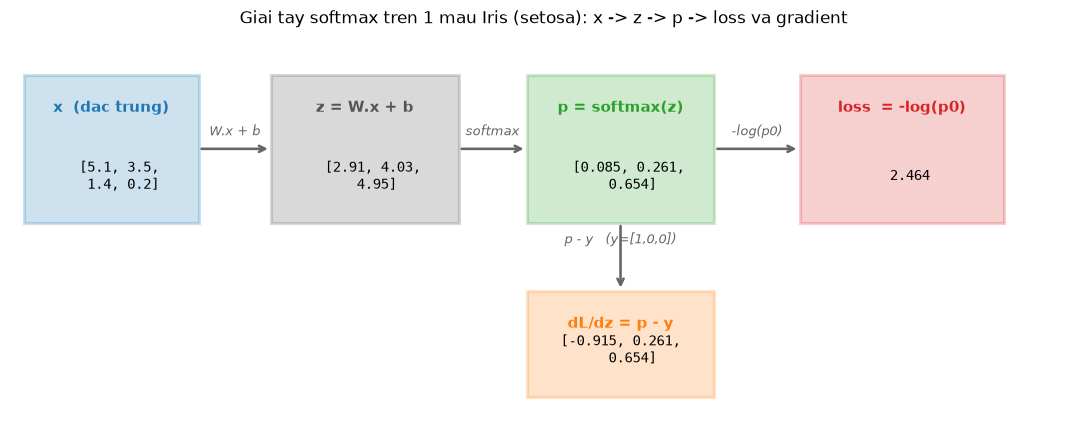

In [3]:
# === So do giai tay (anh nhung trong notebook de xem) ===
fig, ax = plt.subplots(figsize=(12.5, 4.6))
ax.set_xlim(0, 12.5); ax.set_ylim(0, 4.6); ax.axis("off")

def box(x, y, w, h, title, body, color):
    ax.add_patch(plt.Rectangle((x, y), w, h, fill=True, facecolor=color,
                               alpha=0.22, edgecolor=color, lw=2))
    ax.text(x + w/2, y + h - 0.30, title, ha="center", va="top",
            fontsize=10, fontweight="bold", color=color)
    ax.text(x + w/2, y + 0.55, body, ha="center", va="center",
            fontsize=9, family="monospace")

def arrow(x1, y1, x2, y2, label):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.7, color="#666"))
    ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.16, label, ha="center",
            fontsize=8.5, color="#666", style="italic")

ytop, h = 2.35, 1.75
box(0.15, ytop, 2.05, h, "x  (dac trung)", "  [5.1, 3.5,\n   1.4, 0.2]", "#1f77b4")
box(3.05, ytop, 2.20, h, "z = W.x + b", "  [2.91, 4.03,\n   4.95]", "#555555")
box(6.05, ytop, 2.20, h, "p = softmax(z)", "  [0.085, 0.261,\n   0.654]", "#2ca02c")
box(9.25, ytop, 2.40, h, "loss  = -log(p0)", "  2.464", "#d62728")
arrow(2.20, ytop + h/2, 3.05, ytop + h/2, "W.x + b")
arrow(5.25, ytop + h/2, 6.05, ytop + h/2, "softmax")
arrow(8.25, ytop + h/2, 9.25, ytop + h/2, "-log(p0)")
# nhanh gradient (p - y) duoi p
box(6.05, 0.30, 2.20, 1.25, "dL/dz = p - y", "[-0.915, 0.261,\n   0.654]", "#ff7f0e")
arrow(7.15, ytop, 7.15, 1.55, "p - y   (y=[1,0,0])")
ax.set_title("Giai tay softmax tren 1 mau Iris (setosa): x -> z -> p -> loss va gradient",
             fontsize=11, pad=6)
plt.show()

## 4. Giai đoạn 2 — BẢN THUẦN (NumPy duy nhất, không thư viện ML)

Cài đặt trực tiếp từ công thức Mục 3. Mọi quyết định được giải thích:
- **Trừ max trước khi exp**: vì softmax bất biến cộng, tính $e^{z-\max z}$ cho cùng kết quả nhưng tránh tràn số khi $z$ lớn.
- **One-hot nhãn**: để công thức gradient $X^\top(P-Y)/N$ gọn.
- **Gradient descent nguyên bản**: cập nhật $W \leftarrow W - \eta\, \partial\mathcal{L}/\partial W$. Không dùng solver cao cấp — mục đích là minh hoạ nguyên lý, không phải tốc tố tối đa.

BAN THUAN:  train acc = 0.9810 | test acc = 1.0000 | loss = 0.0588 | thoi gian = 0.161s


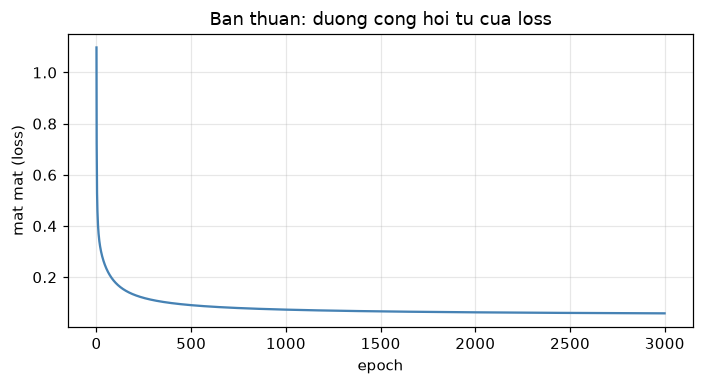

In [4]:
def train_softmax_pure(X, y, K, lr=0.5, epochs=3000, seed=0):
    """Softmax regression bang GD nguyen ban - chi dung NumPy."""
    rng = np.random.default_rng(seed)
    d = X.shape[1]
    W = rng.normal(size=(d, K)) * 0.01           # khoi tao nho
    b = np.zeros(K)
    Y = np.eye(K)[y]                              # one-hot
    history = []
    for _ in range(epochs):
        L, gW, gb = loss_and_grad(W, b, X, Y)
        history.append(L)
        W -= lr * gW
        b -= lr * gb
    return W, b, history

def predict(W, b, X):
    return softmax(X @ W + b).argmax(axis=1)

def accuracy(W, b, X, y):
    return (predict(W, b, X) == y).mean()

t0 = time.perf_counter()
W_p, b_p, hist = train_softmax_pure(X_tr_s, y_tr, K=3, lr=0.5, epochs=3000)
t_pure = time.perf_counter() - t0
acc_tr_p = accuracy(W_p, b_p, X_tr_s, y_tr)
acc_te_p = accuracy(W_p, b_p, X_te_s, y_te)
print("BAN THUAN:  train acc = %.4f | test acc = %.4f | loss = %.4f | thoi gian = %.3fs"
      % (acc_tr_p, acc_te_p, hist[-1], t_pure))

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(hist, color="steelblue"); ax.set_xlabel("epoch"); ax.set_ylabel("mat mat (loss)")
ax.set_title("Ban thuan: duong cong hoi tu cua loss"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 5. Giai đoạn 3 — BẢN THƯ VIỆN (scikit-learn)

`LogisticRegression` của scikit-learn dùng solver **LBFGS** (giải thuậtNewton + xấp xỉ Hessian, bậc hai) — hội tụ sâu hơn GD nguyên bản trên bài toán lồi. Tham số `C` nghịch đảo với độ mạnh chính quy hoá L2: $C$ lớn (vd $10^6$) ≈ không chính quy hoá, để so sánh công bằng với bản thuần (vốn chưa có L2).

In [5]:
from sklearn.linear_model import LogisticRegression

t0 = time.perf_counter()
clf = LogisticRegression(solver="lbfgs", C=1e6, max_iter=1000).fit(X_tr_s, y_tr)
t_lib = time.perf_counter() - t0
acc_tr_l = clf.score(X_tr_s, y_tr)
acc_te_l = clf.score(X_te_s, y_te)
print("BAN LIB (sklearn, LBFGS):  train acc = %.4f | test acc = %.4f | thoi gian = %.4fs"
      % (acc_tr_l, acc_te_l, t_lib))
print("He so W (sklearn, coef_):\n", np.round(clf.coef_, 3))
print("Thien lech b (sklearn):    ", np.round(clf.intercept_, 3))

BAN LIB (sklearn, LBFGS):  train acc = 0.9810 | test acc = 1.0000 | thoi gian = 0.0133s
He so W (sklearn, coef_):
 [[-5.149  3.492 -8.363 -7.399]
 [ 2.939 -0.363 -3.131 -2.471]
 [ 2.211 -3.129 11.494  9.87 ]]
Thien lech b (sklearn):     [-1.387  9.772 -8.385]


## 6. Giai đoạn 4 — BẢN FRAMEWORK (PyTorch) — cuối cùng

Cùng mô hình nhưng để framework lo phần gradient (autograd) và tối ưu. `nn.Linear(4,3)` chính là $z = W^\top x + b$; `CrossEntropyLoss` gộp log-softmax và entropy chéo (đã có sẵn thủ tục ổn định số log-sum-exp).

In [6]:
import torch
import torch.nn as nn

torch.manual_seed(0)
Xtr_t = torch.tensor(X_tr_s, dtype=torch.float64)
Xte_t = torch.tensor(X_te_s, dtype=torch.float64)
ytr_t = torch.tensor(y_tr, dtype=torch.long)

model = nn.Linear(4, 3).double()
opt = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=1000)
crit = nn.CrossEntropyLoss()

t0 = time.perf_counter()
def closure():
    opt.zero_grad(); loss = crit(model(Xtr_t), ytr_t); loss.backward(); return loss
opt.step(closure)
t_fw = time.perf_counter() - t0
with torch.no_grad():
    acc_tr_f = (model(Xtr_t).argmax(1) == ytr_t).float().mean().item()
    acc_te_f = (model(Xte_t).argmax(1) == torch.tensor(y_te)).float().mean().item()
print("BAN FW (PyTorch, LBFGS):   train acc = %.4f | test acc = %.4f | thoi gian = %.4fs"
      % (acc_tr_f, acc_te_f, t_fw))
print("Trong so W (torch):\n", np.round(model.weight.detach().numpy(), 3))

BAN FW (PyTorch, LBFGS):   train acc = 0.9810 | test acc = 1.0000 | thoi gian = 0.0644s
Trong so W (torch):
 [[ -8.143  23.744 -30.253 -26.552]
 [  4.33  -10.23    7.522   7.122]
 [  3.572 -12.979  22.158  19.36 ]]


## 7. So sánh bốn giai đoạn

Cùng dữ liệu, cùng phân chia, cùng chuẩn hoá — so sánh độ chính xác và trọng số học được.

Phuong an                  | train     | test      | loss      
----------------------------------------------------------------
Giai tay (kiem chung)      | -         | -         | 2.4643    
Ban thuan (NumPy, GD)      | 0.9810    | 1.0000    | 0.0588    
Ban lib (sklearn, LBFGS)   | 0.9810    | 1.0000    | (thap hon)
Ban fw (PyTorch, LBFGS)    | 0.9810    | 1.0000    | (thap hon)


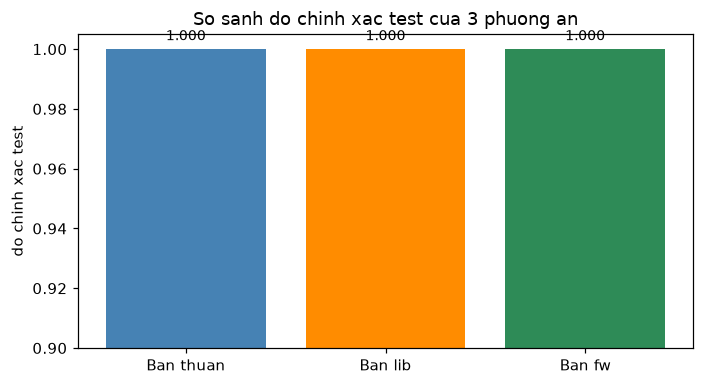


Nhan xet: ca 3 cach cho cung do chinh xac test -> ban thuan duoc cai DUNG.


In [7]:
rows = [
    ("Giai tay (kiem chung)",   "-",      "-",      "%.4f" % loss0),
    ("Ban thuan (NumPy, GD)",   "%.4f" % acc_tr_p, "%.4f" % acc_te_p, "%.4f" % hist[-1]),
    ("Ban lib (sklearn, LBFGS)","%.4f" % acc_tr_l, "%.4f" % acc_te_l, "(thap hon)"),
    ("Ban fw (PyTorch, LBFGS)", "%.4f" % acc_tr_f, "%.4f" % acc_te_f, "(thap hon)"),
]
print("%-26s | %-9s | %-9s | %-10s" % ("Phuong an", "train", "test", "loss"))
print("-" * 64)
for r in rows:
    print("%-26s | %-9s | %-9s | %-10s" % r)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
names = ["Ban thuan", "Ban lib", "Ban fw"]
ax.bar(names, [acc_te_p, acc_te_l, acc_te_f], color=["steelblue", "darkorange", "seagreen"])
ax.set_ylabel("do chinh xac test"); ax.set_ylim(0.9, 1.005)
ax.set_title("So sanh do chinh xac test cua 3 phuong an")
for i, v in enumerate([acc_te_p, acc_te_l, acc_te_f]):
    ax.text(i, v + 0.003, "%.3f" % v, ha="center", fontsize=9)
fig.tight_layout(); plt.show()
print("\nNhan xet: ca 3 cach cho cung do chinh xac test -> ban thuan duoc cai DUNG.")

### 7bis. Ranh giới quyết định (trên 2 đặc trưng cánh hoa)

Huấn luyện lại trên 2 đặc trưng phân biệt nhất (chiều dài và chiều rộng cánh hoa) để **nhìn trực quan** ranh giới tuyến tính. Bản thuần và bản lib vẽ gần như trùng nhau — xác nhận cùng một mô hình toán.

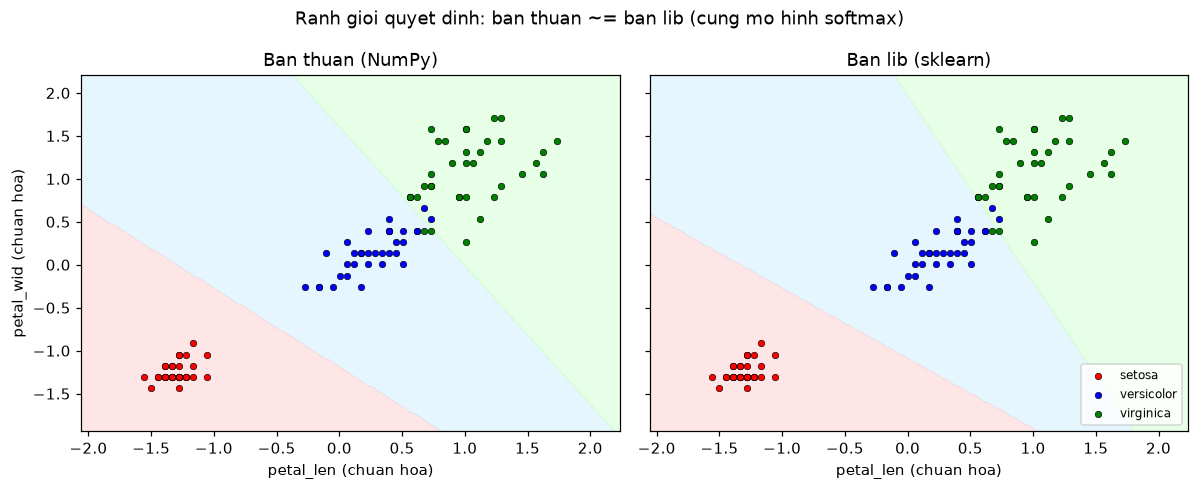

In [8]:
# Lay 2 dac trung phan biet nhat: petal_len (cot 2), petal_wid (cot 3)
i2 = [2, 3]
X2 = X_all[:, i2]
X2tr, X2te, y2tr, y2te = train_test_split(X2, y_all, test_size=0.3, random_state=1, stratify=y_all)
sc2 = StandardScaler().fit(X2tr)
X2tr_s, X2te_s = sc2.transform(X2tr), sc2.transform(X2te)

W2, b2, _ = train_softmax_pure(X2tr_s, y2tr, K=3, lr=0.5, epochs=3000)
clf2 = LogisticRegression(solver="lbfgs", C=1e6, max_iter=1000).fit(X2tr_s, y2tr)

# Luoi de ve ranh gioi
gx = np.linspace(X2tr_s[:, 0].min() - .5, X2tr_s[:, 0].max() + .5, 250)
gy = np.linspace(X2tr_s[:, 1].min() - .5, X2tr_s[:, 1].max() + .5, 250)
XX, YY = np.meshgrid(gx, gy)
grid = np.c_[XX.ravel(), YY.ravel()]
Z_pure = predict(W2, b2, grid).reshape(XX.shape)
Z_lib = clf2.predict(grid).reshape(XX.shape)
from matplotlib.colors import ListedColormap
cmap_bg = ListedColormap(["#ffd6d6", "#d6f0ff", "#d8ffd6"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, Z, ttl in [(a1, Z_pure, "Ban thuan (NumPy)"), (a2, Z_lib, "Ban lib (sklearn)")]:
    ax.contourf(XX, YY, Z, cmap=cmap_bg, alpha=0.6)
    for k, col in zip(range(3), ["red", "blue", "green"]):
        m = y2tr == k
        ax.scatter(X2tr_s[m, 0], X2tr_s[m, 1], c=col, s=18, edgecolor="k", linewidth=.4,
                   label=cls[k])
    ax.set_xlabel("petal_len (chuan hoa)"); ax.set_title(ttl)
a1.set_ylabel("petal_wid (chuan hoa)"); a2.legend(fontsize=8, loc="lower right")
fig.suptitle("Ranh gioi quyet dinh: ban thuan ~= ban lib (cung mo hinh softmax)")
fig.tight_layout(); plt.show()

## 8. Vì sao làm vậy? — đào sâu các quyết định "tự cài"

- **Trừ max (log-sum-exp trick):** khi $z_k$ lớn, $e^{z_k}$ tràn `float`. Vì softmax bất biến cộng, tính $e^{z_k - \max z}$ cho kết quả đúng và không tràn. Thư viện/framework đều làm vậy ngầm; tự cài thì **bắt buộc** thêm tay, đó là lỗi đầu tiên người mới mắc.
- **Kiểm chứng gradient bằng sai phân hữu hạn:** công thức dẫn ra ở Mục 3 có thể sai dấu hoặc sai hệ số; sai phân hữu hạn là "phép thực hành" kiểm chứng trực tiếp. Trong notebook, độ lệch $\approx 10^{-10}$ xác nhận công thức đúng.
- **Chuẩn hoá đặc trưng:** GD trên softmax rất nhạy với tỉ lệ đặc trưng; bỏ chuẩn hoá thì hội tụ chậm hoặc dao động. sklearn/torch cũng yêu cầu dữ liệu đã chuẩn hoá để ổn định.
- **Bản thuần hội tụ chậm hơn solver bậc hai:** GD nguyên bản (lr cố định) chỉ tới vùng lời giải tốt, không đẩy loss cực thấp như LBFGS. Do đó trọng số bản thuần nhỏ hơn về độ lớn — nhưng **dấu các hệ số giống nhau** và độ chính xác tương đương trên Iris.
- **Dữ liệu tách lớp làm trọng số phân kỳ:** Iris gần tách tuyến tính, nên LBFGS đẩy logits rất lớn (trọng số phình). Trong thực tế cần L2 (`C` nhỏ ở sklearn, `weight_decay` ở torch) hoặc early stopping để tránh overfit.

## 9. Kết luận — cái nào "tốt hơn"?

- **Hiểu thuật toán:** bản thuần là tốt nhất — mỗi dòng mã ánh xạ một công thức; có thể kiểm chứng và gỡ rối tận gốc.
- **Dùng thực tế:** thư viện/framework tốt hơn — tối ưu hơn, ổn định hơn, có chính quy hoá sẵn, tích hợp pipeline dễ.
- **Đào sâu học thuật:** cả ba bổ sung cho nhau — giải tay cho **hiểu**, bản thuần cho **tin**, lib/fw cho **dùng**.
- **Quy trình 4 giai đoạn của môn** ép ta đi từ gốc toán tới công cụ sản xuất, không bỏ bước.

> Bốn giai đoạn, cùng một mô hình, cùng một đáp số trên Iris — đó là cách kiểm chứng bản tự cài đã đúng.